### Step 1 - Import libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

### Step 2 - Load the raw data

In [3]:
# Load raw data — this is the unmodified file straight from UCI
df_raw = pd.read_csv('../data/online_retail_II.csv', encoding="utf-8")

print(f"Raw Shape: {df_raw.shape[0]:,} rows {df_raw.shape[1]} columns")
print()
df_raw.head(10)

Raw Shape: 1,067,371 rows 8 columns



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [4]:
# Check data types — are they what we expect?
print("Column data types:")
print(df_raw.dtypes)

Column data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [12]:
# Check for missing values — which columns have gaps and how many?
print("Missing Values per column:")

# Count missing values in each column
missing = df_raw.isnull().sum()

# Calculate missing percentage for each column
missing_pct = (missing / len(df_raw) * 100).round(2)

# Create a summary table
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Show all columns missing counts if it is still 0
print(missing_df)

# Show only columns where missing count is greater than 0
# print(missing_df[missing_df['Missing Count'] > 0])

print()

# Print total number of rows in the dataset
print(f"Total rows: {len(df_raw):,}")

print()

Missing Values per column:
             Missing Count  Missing %
Invoice                  0       0.00
StockCode                0       0.00
Description           4382       0.41
Quantity                 0       0.00
InvoiceDate              0       0.00
Price                    0       0.00
Customer ID         243007      22.77
Country                  0       0.00

Total rows: 1,067,371



In [13]:
print("Key problems found:")
print(f"  • Customer ID: {missing['Customer ID']:,} nulls ({missing_pct['Customer ID']}%) — guest/anonymous transactions")
print(f"  • Description: {missing['Description']:,} nulls ({missing_pct['Description']}%) — minor, won't affect analysis")

Key problems found:
  • Customer ID: 243,007 nulls (22.77%) — guest/anonymous transactions
  • Description: 4,382 nulls (0.41%) — minor, won't affect analysis


In [ ]:
# Check for cancellations — invoices starting with 'C'
# Convert Invoice to string, check which values start with 'C' using startswith(),
# and filter df_raw to keep only those cancellation rows
cancellations = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
print(f"Cancellations rows (Start with 'C'): {len(cancellations):,}")
print(f"% of total rows: {len(cancellations)/len(df_raw)*100:.2f}")
print()
print("Sample cancellations:")
cancellations.head(10)

Cancellations rows (Start with 'C'): 19,494
% of total rows: 1.83

Sample cancellations:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [19]:
# Count rows with non-positive Quantity or Price values, then inspect sample rows
# where Quantity is negative to identify returns, cancellations, or invalid records.
print(f"Rows with Quantity <= 0: {(df_raw['Quantity'] <= 0 ).sum():,}")
print(f"Rows with Price <= 0: {(df_raw['Price'] <= 0 ).sum():,}")

print()
print("Sample negative quantities:")

df_raw[df_raw['Quantity'] < 0][
    ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
].head(5)


Rows with Quantity <= 0: 22,950
Rows with Price <= 0: 6,207

Sample negative quantities:


,Invoice,StockCode,Description,Quantity,Price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25
181,C489449,21896,POTTING SHED TWINE,-6,2.10
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95


In [20]:
# Summary of all problems found in raw data
print("=" * 50)
print("RAW DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total rows:                    {len(df_raw):,}")
print(f"Rows with null Customer ID:    {df_raw['Customer ID'].isnull().sum():,}")
print(f"Cancellation invoices (C...):  {df_raw['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Rows with Quantity <= 0:       {(df_raw['Quantity'] <= 0).sum():,}")
print(f"Rows with Price <= 0:          {(df_raw['Price'] <= 0).sum():,}")
print("=" * 50)

RAW DATA QUALITY SUMMARY
Total rows:                    1,067,371
Rows with null Customer ID:    243,007
Cancellation invoices (C...):  19,494
Rows with Quantity <= 0:       22,950
Rows with Price <= 0:          6,207


### Step 3 - Data Cleanig

In [21]:
# Cleaning summary:
# 1. Remove rows with missing Customer ID because anonymous customers cannot be used
#    for customer-level analysis such as RFM, CLV, or customer profiling.

# 2. Remove cancellation rows where Invoice starts with 'C' because these are refunds/returns,
#    not real earned sales, and they can distort revenue and recency calculations.

# 3. Remove rows where Quantity <= 0 or Price <= 0 because negative/zero values usually represent
#    returns, stock adjustments, free samples, errors, or test records rather than genuine purchases.

In [23]:
# start with copy of the raw data so we can always go back to it
df = df_raw.copy()
print(f"Starting rows: {len(df):,}")
print()

# Cleaning Step - 1: Drop rows with no customer ID
before = len(df)
df = df.dropna(subset=['Customer ID'])
removed = before - len(df)
print(f"Step 1 - Drop Null customer ID: removed {removed:,} rows:{len(df):,} remaining")

Starting rows: 1,067,371

Step 1 - Drop Null customer ID: removed 243,007 rows:824,364 remaining


In [ ]:
# cleaning Step - 2: Remove Cancellations
before =  len(df)
# startswith('C') returns True for cancelled invoices,
# ~ reverses True to False, so df[...] keeps only non-cancelled invoices.
df = df[~df['Invoice'].astype(str).str.startswith('C')]
removed = before - len(df)
print(f"Step 2 - Remove Cancellations: removed {removed:,} rows: {len(df):,} remaining")

Step 2 - Remove Cancellations: removed 0 rows: 805,620 remaining


In [26]:
# Cleaning step - 3: Remove invalid quantities and prices
before = len(df)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
removed = before - len(df)
print(f"Step 3 - Remove Invalid Qty/Price: removed {removed:,} rows: {len(df):,} remaining")

Step 3 - Remove Invalid Qty/Price: removed 71 rows: 805,549 remaining


In [27]:
print(f"Raw rows:   {len(df_raw):,}")
print(f"Clean rows: {len(df):,}")
print(f"Removed:    {len(df_raw) - len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")

Raw rows:   1,067,371
Clean rows: 805,549
Removed:    261,822 (24.5%)


In [ ]:
# Fix data types
print("Column data types:")
print(df.dtypes)

# Parse InvoiceDate as a proper datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

print("Data Types after fixing: ")
print(df.dtypes)
print()
print(f"Date range: {df['InvoiceDate'].min().date()} - {df['InvoiceDate'].max().date()}")

Column data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
Data Types after fixing: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object

Date range: 2009-12-01 - 2011-12-09


In [31]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom


In [32]:
# Create TotalRevenue column
df['TotalRevenue'] = df['Quantity'] * df['Price']
print()

In [33]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,45.0


In [ ]:
# total revenue, average revenue per transaction line, number of unique customers,
# and number of unique products
print(f"Total revenue across all transactions: £{df['TotalRevenue'].sum():,.2f}")
print(f"Average revenue per line item:         £{df['TotalRevenue'].mean():.2f}")
print(f"Unique customers:                      {df['Customer ID'].nunique():,}")
print(f"Unique products:                       {df['StockCode'].nunique():,}")
print()

# Display descriptive statistics for important numeric columns
# to understand quantity, price, and revenue distribution
df[['Quantity', 'Price', 'TotalRevenue']].describe().round(2)

Total revenue across all transactions: £17,743,429.18
Average revenue per line item:         £22.03
Unique customers:                      5,878
Unique products:                       4,631



,Quantity,Price,TotalRevenue
count,805549.00,805549.00,805549.00
mean,13.29,3.21,22.03
std,143.63,29.20,224.04
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,5.00,1.95,11.85
75%,12.00,3.75,19.50
max,80995.00,10953.50,168469.60


In [35]:
# Final check — confirm no nulls remain in key columns
print("Null check on clean data:")
key_cols = ['Invoice', 'Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'TotalRevenue']
print(df[key_cols].isnull().sum())
print()
print("Clean data sample:")
df.head(5)

Null check on clean data:
Invoice         0
Customer ID     0
InvoiceDate     0
Quantity        0
Price           0
TotalRevenue    0
dtype: int64

Clean data sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


### Step 4 - Exploratory Data Analysis (EDA)

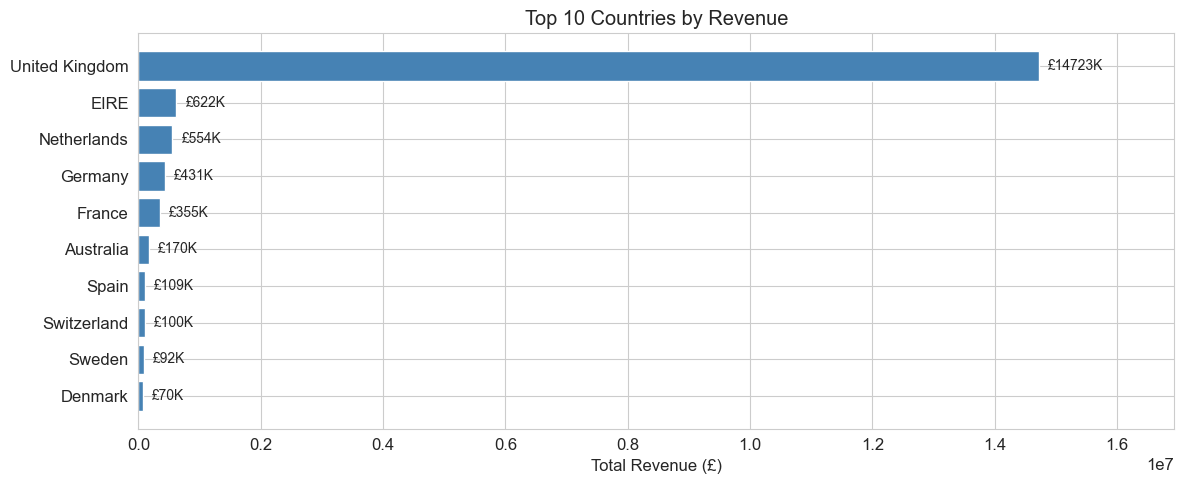

The UK dominates — this is a UK-based retailer with mostly domestic customers.


In [78]:
# Top 10 countries by revenue
# Group the data by Country, then calculate total revenue for each country
country_rev = (
    df.groupby('Country')['TotalRevenue']
    
    # Add all TotalRevenue values within each country
    .sum()
    
    # Sort countries from highest revenue to lowest revenue
    .sort_values(ascending=False)
    
    # Keep only the top 10 countries by revenue
    .head(10)
    
    # Convert the grouped result back into a normal DataFrame
    .reset_index()
)

# Create the chart area
fig, ax = plt.subplots()

# Create a horizontal bar chart
# [::-1] reverses the order so the highest revenue country appears at the top
bars = ax.barh(
    country_rev['Country'][::-1],        # Country names on the y-axis
    country_rev['TotalRevenue'][::-1],   # Revenue values on the x-axis
    color='steelblue'                    # Bar color
)

# Add label to the x-axis
ax.set_xlabel('Total Revenue (£)')

# Add chart title
ax.set_title('Top 10 Countries by Revenue')

# Add extra space on the right side so data labels do not go outside the chart
ax.set_xlim(0, country_rev['TotalRevenue'].max() * 1.15)

# Loop through each bar and its matching revenue value
for bar, val in zip(bars, country_rev['TotalRevenue'][::-1]):

    # Add a text label at the end of each bar
    ax.text(
        bar.get_width() + country_rev['TotalRevenue'].max() * 0.01,  # x-position: slightly after bar end
        bar.get_y() + bar.get_height() / 2,                          # y-position: middle of the bar
        f'£{val/1e3:.0f}K',                                          # format revenue in thousands
        va='center',                                                 # vertically align text in center
        fontsize=10                                                  # text size
    )

# Adjust spacing so labels and title fit properly
plt.tight_layout()

# Display the chart
plt.show()

# Print a simple business insight from the chart
print("The UK dominates — this is a UK-based retailer with mostly domestic customers.")



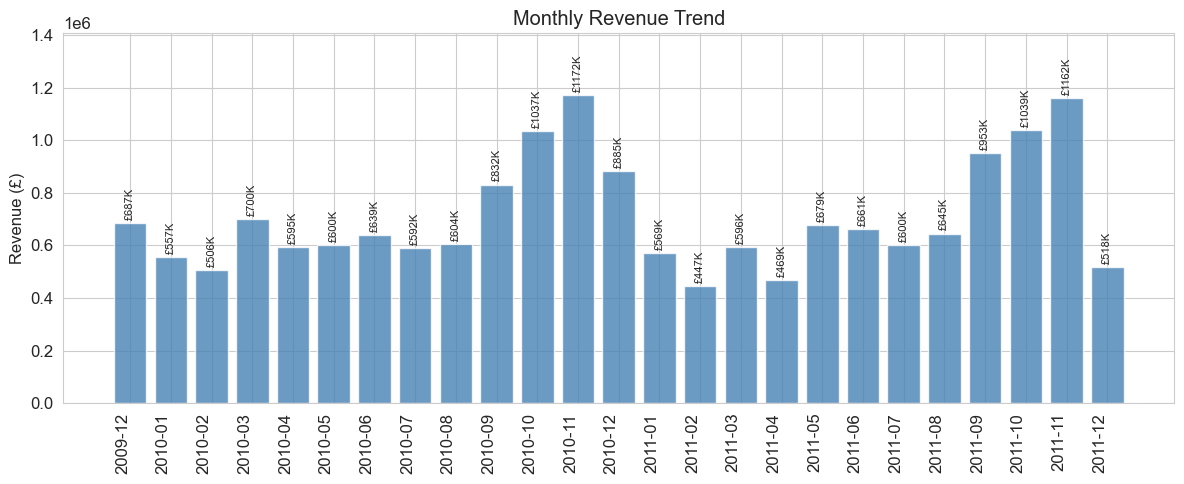

In [77]:
import matplotlib.pyplot as plt

# Create YearMonth column in simple year-month format
df['YearMonth'] = df['InvoiceDate'].dt.strftime('%Y-%m')

# Calculate monthly total revenue
monthly = df.groupby('YearMonth')['TotalRevenue'].sum().reset_index()

# Create chart with fixed size
fig, ax = plt.subplots(figsize=(12, 5))

# Plot monthly revenue
bars = ax.bar(
    monthly['YearMonth'],
    monthly['TotalRevenue'],
    color='steelblue',
    alpha=0.8
)

# Add data labels on top of bars
for bar, val in zip(bars, monthly['TotalRevenue']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + monthly['TotalRevenue'].max() * 0.01,
        f'£{val/1e3:.0f}K',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

# Add title and axis label
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Revenue (£)')

# Add extra space at the top for labels
ax.set_ylim(0, monthly['TotalRevenue'].max() * 1.20)

# Rotate x-axis labels
plt.xticks(rotation=90, ha='right')

# Prevent layout from creating an extremely large image
plt.tight_layout()

# Display chart
plt.show()

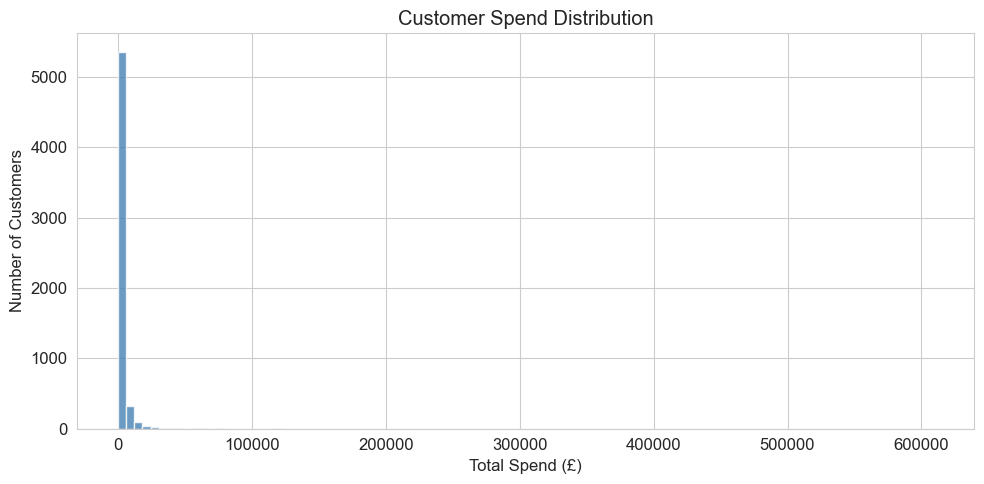

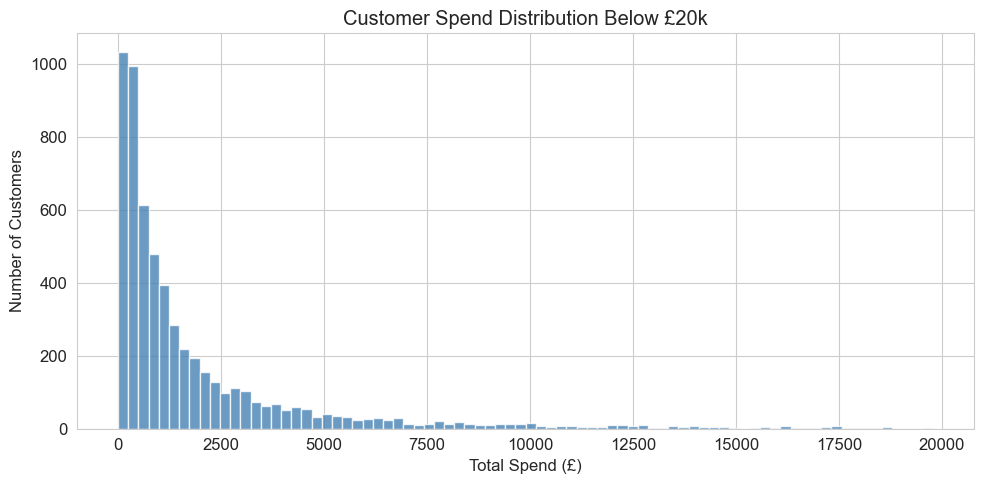

Top 20% of customers (1,175) generate 77.2% of revenue
Revenue is highly concentrated — a small number of customers matter a lot.


In [76]:
# Calculate total spend for each customer
customer_spend = df.groupby('Customer ID')['TotalRevenue'].sum()

# Plot full customer spend distribution
plt.figure(figsize=(10, 5))
plt.hist(customer_spend, bins=100, color='steelblue', alpha=0.8)

plt.title('Customer Spend Distribution')
plt.xlabel('Total Spend (£)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()


# Plot customer spend distribution below £20,000
# This removes very high-spending customers so the normal pattern is easier to see
plt.figure(figsize=(10, 5))
plt.hist(customer_spend[customer_spend < 20000], bins=80, color='steelblue', alpha=0.8)

plt.title('Customer Spend Distribution Below £20k')
plt.xlabel('Total Spend (£)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()


# Sort customers from highest spender to lowest spender
sorted_spend = customer_spend.sort_values(ascending=False)

# Find how many customers are in the top 20%
top20_count = int(len(sorted_spend) * 0.20)

# Calculate revenue generated by the top 20% customers
top20_revenue = sorted_spend.head(top20_count).sum()

# Calculate total revenue from all customers
total_revenue = sorted_spend.sum()

# Calculate revenue percentage contributed by the top 20% customers
top20_percentage = top20_revenue / total_revenue * 100

print(f"Top 20% of customers ({top20_count:,}) generate {top20_percentage:.1f}% of revenue")
print("Revenue is highly concentrated — a small number of customers matter a lot.")

In [72]:
# Count unique orders for each customer
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()

# Count customers by order frequency
one_time_customers = (orders_per_customer == 1).sum()
two_to_five_customers = orders_per_customer.between(2, 5).sum()
six_plus_customers = (orders_per_customer >= 6).sum()

# Calculate percentage of one-time customers
one_time_pct = one_time_customers / len(orders_per_customer) * 100

# Print results
print(f"Customers who bought only once: {one_time_customers:,} ({one_time_pct:.1f}%)")
print(f"Customers who bought 2–5 times: {two_to_five_customers:,}")
print(f"Customers who bought 6+ times: {six_plus_customers:,}")

print()
print("A large portion are one-time buyers - predicting who will come back")

Customers who bought only once: 1,623 (27.6%)
Customers who bought 2–5 times: 2,454
Customers who bought 6+ times: 1,801

A large portion are one-time buyers - predicting who will come back


### Step 5 - Save clean data

In [74]:
# Save the cleaned DataFrame as a CSV file
# index=False prevents pandas from saving the DataFrame index as an extra column
df.to_csv('../data/clean_data.csv', index=False)

# Confirm that the cleaned file has been saved
print("Saved: ../data/clean_data.csv")
print()

# Print separator line for cleaner output
print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)

# Show total number of rows in the original raw dataset
print(f"Raw rows:        {len(df_raw):,}")

# Show total number of rows after cleaning
print(f"Clean rows:      {len(df):,}")

# Show how many rows were removed and what percentage of raw data was removed
print(f"Removed:         {len(df_raw)-len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")

# Count unique customers in the cleaned dataset
print(f"Unique customers:{df['Customer ID'].nunique():,}")

# Count unique products in the cleaned dataset
print(f"Unique products: {df['StockCode'].nunique():,}")

# Show the first and last invoice dates in the cleaned dataset
print(f"Date range:      {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

# Show total revenue from the cleaned dataset
print(f"Total revenue:   £{df['TotalRevenue'].sum():,.2f}")

# Print closing separator line
print("=" * 45)
print()


Saved: ../data/clean_data.csv

CLEANING SUMMARY
Raw rows:        1,067,371
Clean rows:      805,549
Removed:         261,822 (24.5%)
Unique customers:5,878
Unique products: 4,631
Date range:      2009-12-01 → 2011-12-09
Total revenue:   £17,743,429.18

